In [1]:
from rotations_fixedpoints import get_system, default_config, configs, output_dir
from misc_utils import read_jsonl_to_df
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

In [2]:
df = pd.concat(
    [
        read_jsonl_to_df(file).assign(file=str(file))
        for file in output_dir.glob("**/*.jsonl")
    ]
).fillna(
    {k: json.dumps(v) if isinstance(v, list) else v for k, v in default_config.items()}
).assign(task_id=lambda x: (x.file.str.extract(r"/(\d+)/").astype(int))).drop('file', axis=1)

[None]

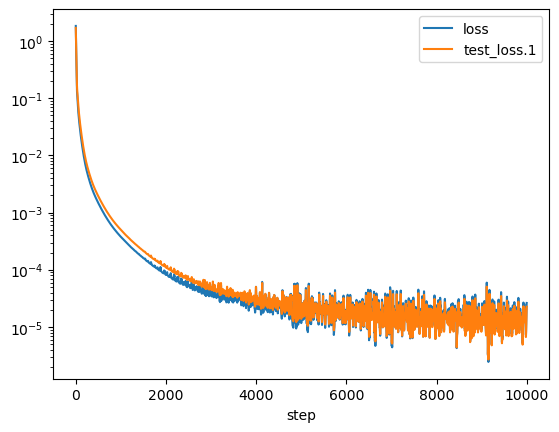

In [3]:
df.query('task_id == 5').plot(x='step', y=['loss', 'test_loss.1']).set(yscale='log')

(0.92, 1.0)

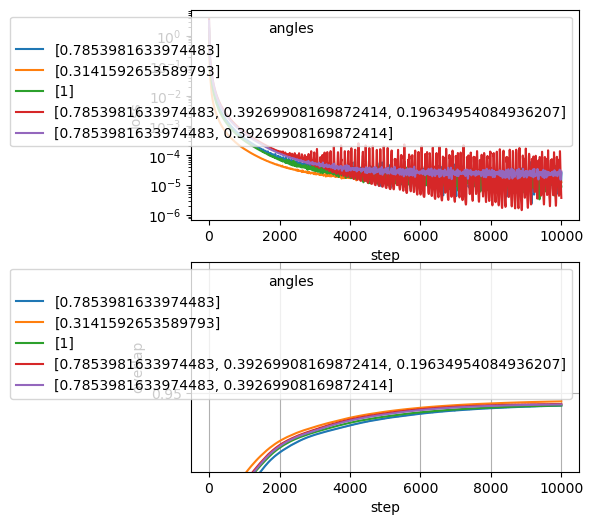

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6))
task_id = 1
sns.lineplot(
    data=df.assign(angles=lambda x: x["angles"].apply(str)),#.query(f"task_id == {task_id}"),
    x="step",
    y="loss", 
    hue='angles', 
    ax=ax1,
).set(yscale="log")
sns.lineplot(
    data=df.assign(angles=lambda x: x["angles"].apply(str)),#.query(f"task_id == {task_id}"),
    x="step",
    y="overlap",
    hue='angles',
    ax=ax2,
)
ax2.grid()
ax2.set_yticks(np.arange(0.35, 1, 0.1))
ax2.set_ylim(0.92, 1)

In [5]:
df.groupby("task_id")['overlap'].last()

task_id
0    0.945206
1    0.946812
2    0.945625
3    0.945791
4    0.945240
5    0.945206
Name: overlap, dtype: float64

In [6]:
sns.relplot(
    df.assign(angles=lambda x: x["angles"].apply(str)),
    x="step",
    y="overlap",
    hue="angles",
    kind="line",
)

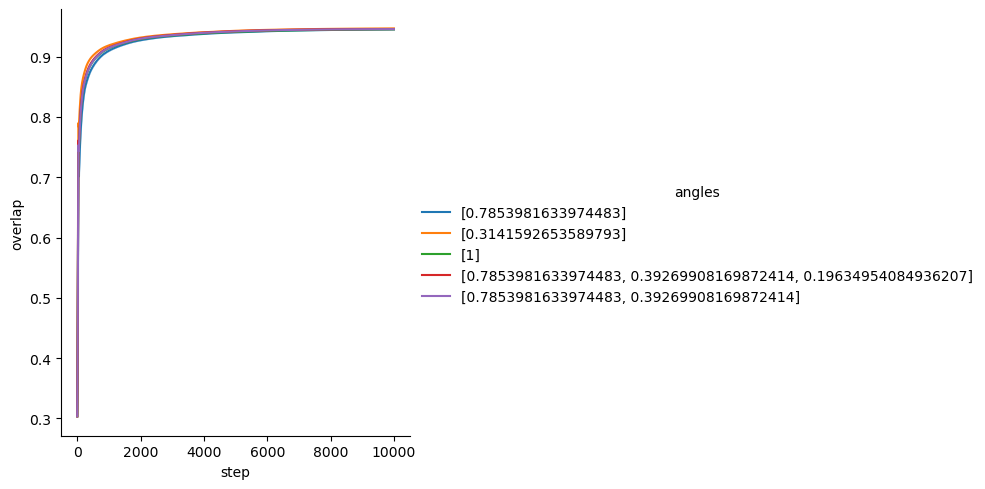

In [ ]:
sns.relplot(
    df.assign(angles=lambda x: x["angles"].apply(str)),
    x="step",
    y="overlap",
    hue="angles",
    kind="line",
)